# 02b — LangChain: Cadenas, Memoria y Recuperación

<figure>
<a
href="https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque2/02b-langchain.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

> Este tema forma parte del **Bloque 2 — Orquestación**. Se recomienda
> haber visto [Prompt Engineering](02a-prompt-engineering.qmd) primero.

In [1]:
!pip install -q langchain langchain-openai langchain-community python-dotenv

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

In [3]:
from langchain_openai import ChatOpenAI

LLM_KEY = os.getenv("LLM_API_KEY")
LLM_URL = "https://llamus.cs.us.es/api/v1"

if not LLM_KEY:
    print("⚠️  Crea un archivo .env en la raíz del proyecto con:\n    LLM_API_KEY=tu_api_key\n    Las celdas siguientes mostrarán este mensaje hasta que configures la clave.")
else:
    llm = ChatOpenAI(model="gemma4:e2b-mlx", base_url=LLM_URL, api_key=LLM_KEY, temperature=0)
    print("✅ ChatOpenAI configurado. Las celdas de ejemplo funcionarán correctamente.")

✅ ChatOpenAI configurado. Las celdas de ejemplo funcionarán correctamente.

## LangChain

### ¿Qué es y para qué sirve?

LangChain es un **framework de orquestación** para aplicaciones con
LLMs. Si usar la API de OpenAI directamente es como cocinar con un solo
fuego, LangChain te da una cocina completa: fogones, temporizador,
nevera con ingredientes y libro de recetas.

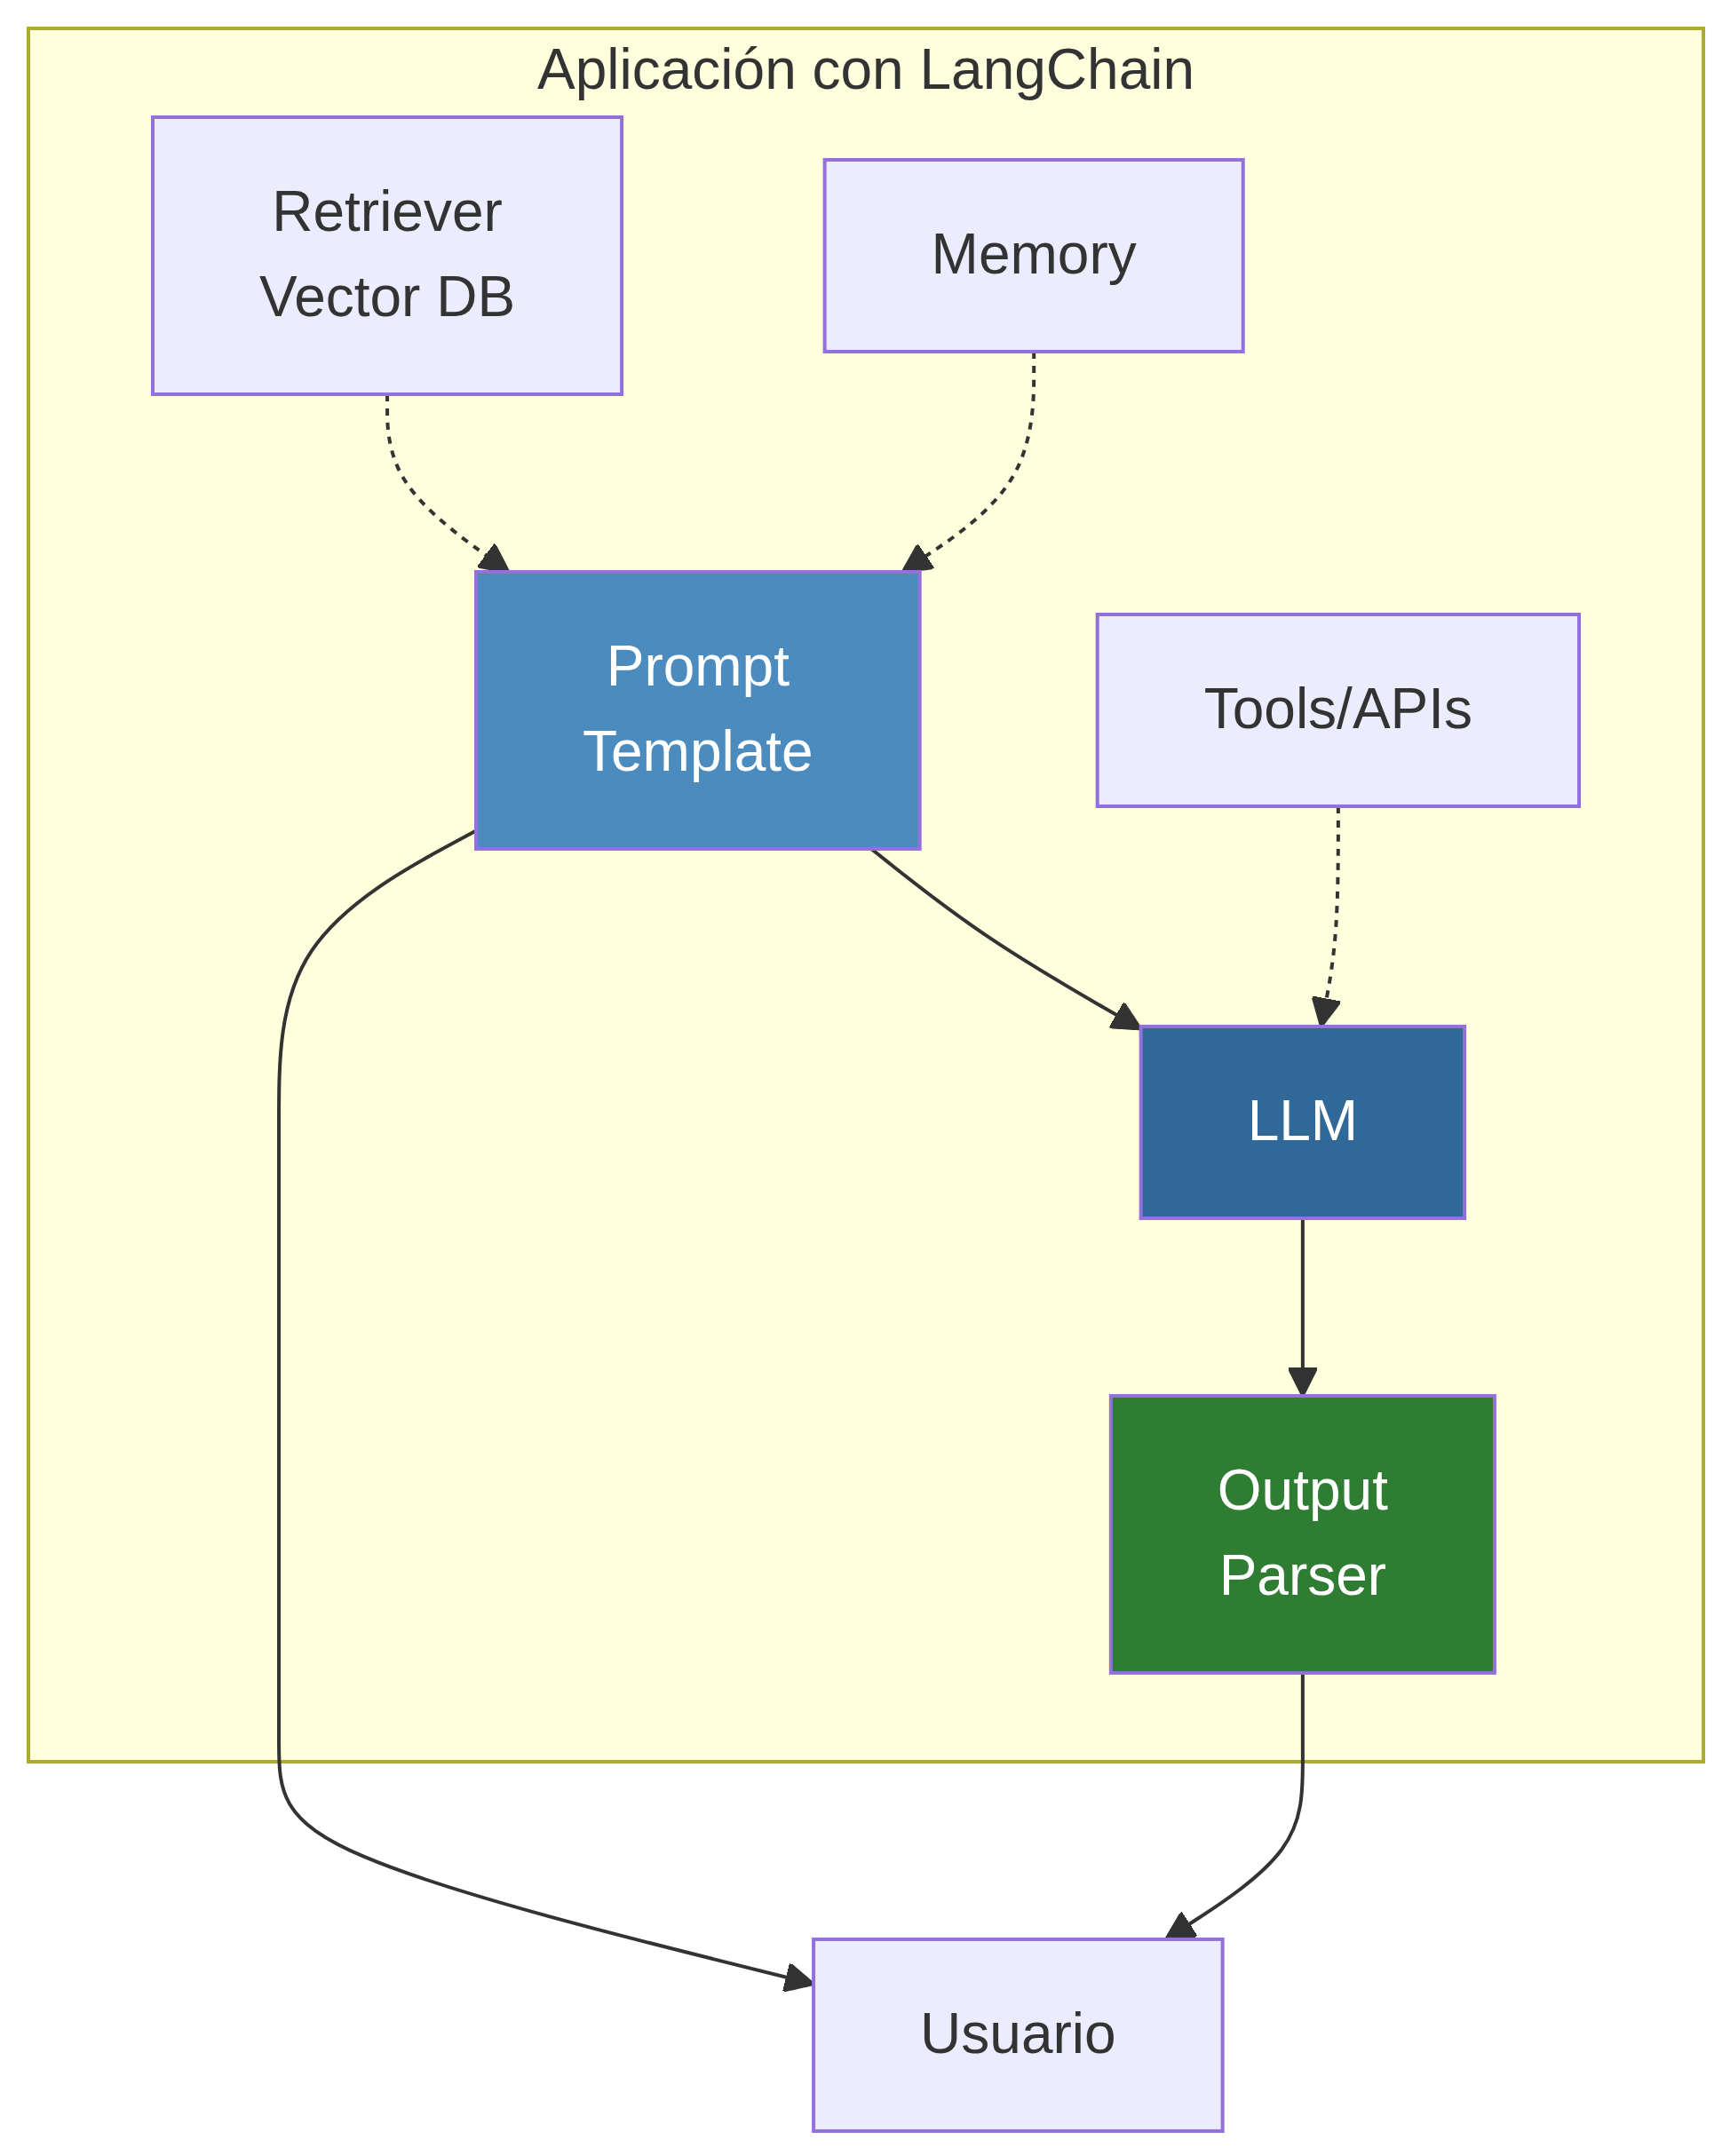

**Componentes clave que veremos:**

| Componente           | ¿Qué hace?                             |
|----------------------|----------------------------------------|
| **Prompt Templates** | Plantillas reutilizables con variables |
| **LCEL**             | Encadenar componentes con `\|`         |
| **Memory**           | Mantener historial de conversación     |
| **Retrievers**       | Buscar documentos relevantes           |
| **Output Parsers**   | Estructurar la salida del modelo       |
| **Callbacks**        | Monitorizar y loguear la ejecución     |

### LCEL — LangChain Expression Language

LCEL usa el operador `|` (pipe) para encadenar componentes, como en las
tuberías de Unix:

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template(
    "Eres un analista de datos. Explica {concepto} en {num_palabras} palabras."
)

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    cadena = prompt | llm | StrOutputParser()
    resultado = cadena.invoke({
        "concepto": "desviación estándar",
        "num_palabras": "50"
    })
    print(resultado)

La desviación estándar mide la dispersión o variabilidad de un conjunto de datos respecto a su media. Indica cuánto se desvían los puntos individuales de la distribución. Una desviación baja significa que los datos están agrupados cerca de la media, mientras que una alta muestra una gran dispersión. Es clave para entender el riesgo.

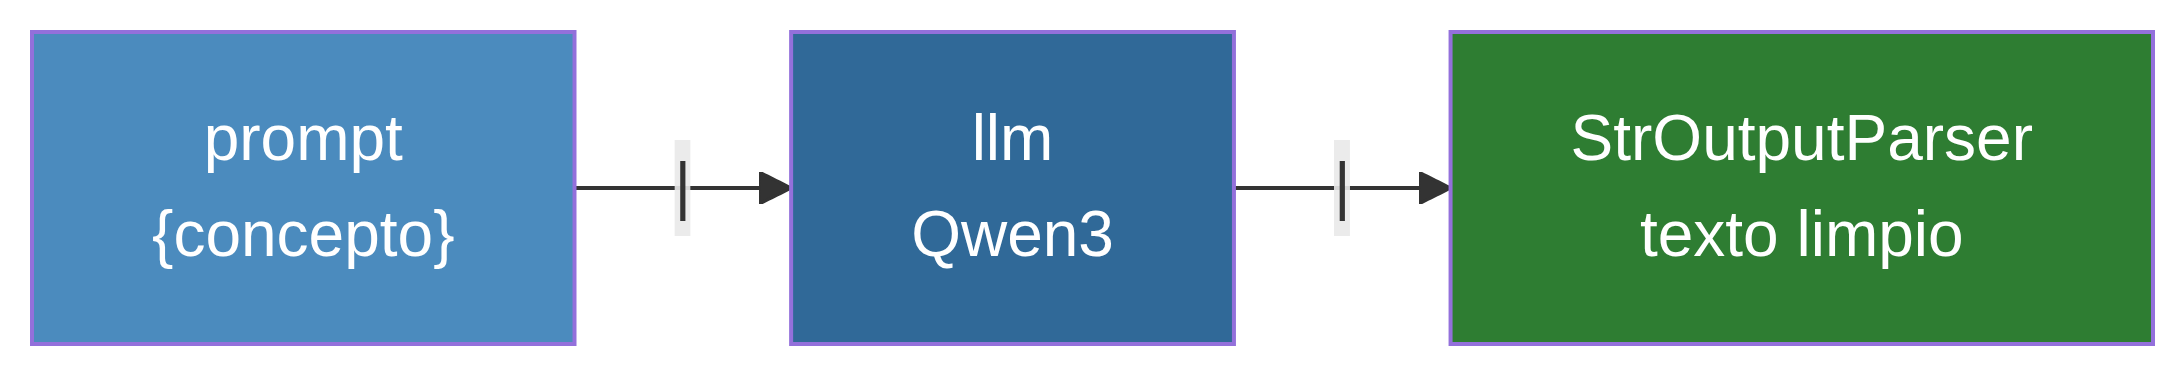

**¿Por qué LCEL?** Esta sintaxis de tubería permite: - Componer cadenas
complejas de forma legible - Ejecución asíncrona, streaming y paralela
sin código extra - Trazabilidad automática con LangSmith

In [5]:
from langchain_core.runnables import RunnableLambda

def procesar_intermedio(texto):
    return texto.upper()

cadena_compleja = prompt | llm | StrOutputParser() | RunnableLambda(procesar_intermedio)

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    print(cadena_compleja.invoke({"concepto": "p-valor", "num_palabras": "30"}))

EL P-VALOR ES LA PROBABILIDAD DE OBSERVAR RESULTADOS TAN EXTREMOS O MÁS SI LA HIPÓTESIS NULA FUERA CIERTA. UN P-VALOR BAJO INDICA QUE EL RESULTADO OBSERVADO ES ESTADÍSTICAMENTE SIGNIFICATIVO.

### Prompt Templates

Las plantillas permiten separar la lógica del prompt del código. Soporta
variables, few-shot examples y carga desde archivo:

In [6]:
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate

plantilla_simple = PromptTemplate.from_template(
    "Genera un resumen de {tipo_documento} sobre {tema} con tono {tono}."
)

print(plantilla_simple.format(
    tipo_documento="informe ejecutivo",
    tema="ventas Q1 2026",
    tono="formal"
))

ejemplos = [
    {"pregunta": "¿Qué es una media?", "respuesta": "La media es la suma dividida por el número de elementos."},
    {"pregunta": "¿Qué es una mediana?", "respuesta": "La mediana es el valor central al ordenar los datos."},
]

plantilla_few_shot = FewShotPromptTemplate(
    examples=ejemplos,
    example_prompt=PromptTemplate.from_template("P: {pregunta}\nR: {respuesta}"),
    prefix="Eres un profesor de estadística. Responde de forma similar a los ejemplos:",
    suffix="P: {pregunta}\nR:",
    input_variables=["pregunta"]
)

print("\n--- Prompt generado con few-shot ---")
print(plantilla_few_shot.format(pregunta="¿Qué es una moda?"))

Genera un resumen de informe ejecutivo sobre ventas Q1 2026 con tono formal.

--- Prompt generado con few-shot ---
Eres un profesor de estadística. Responde de forma similar a los ejemplos:

P: ¿Qué es una media?
R: La media es la suma dividida por el número de elementos.

P: ¿Qué es una mediana?
R: La mediana es el valor central al ordenar los datos.

P: ¿Qué es una moda?
R:

### Memoria conversacional

Sin memoria, cada llamada al LLM es independiente: el modelo no recuerda
lo que dijiste antes. La memoria almacena el historial y lo inyecta en
cada nuevo prompt:

In [7]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory

llm_chat = ChatOpenAI(model="gemma4:e2b-mlx", base_url=LLM_URL, api_key=LLM_KEY, temperature=0.7)

prompt_con_memoria = ChatPromptTemplate.from_messages([
    ("system", "Eres un profesor de estadística amable. Responde en 2 frases máximo."),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}")
])

cadena_con_historial = RunnableWithMessageHistory(
    prompt_con_memoria | llm_chat,
    lambda session_id: ChatMessageHistory(),
    input_messages_key="input",
    history_messages_key="history"
)

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    r1 = cadena_con_historial.invoke(
        {"input": "¿Qué es la desviación estándar?"},
        config={"configurable": {"session_id": "alumno_01"}}
    )
    print("R1:", r1.content)

    r2 = cadena_con_historial.invoke(
        {"input": "¿Y cómo se relaciona con la varianza?"},
        config={"configurable": {"session_id": "alumno_01"}}
    )
    print("R2:", r2.content)

/home/adam/Escritorio/m10_quarto/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3748: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)

R1: La desviación estándar mide qué tan dispersos o separados están los datos respecto a su promedio. Un valor pequeño indica que los datos están agrupados cerca de la media, mientras que un valor grande muestra una gran variabilidad.
R2: La varianza mide qué tan dispersos están los datos en relación con el promedio. Nos indica cuánto se alejan los valores individuales respecto al valor central.

> **Tipos de memoria en LangChain**
>
> | Tipo | Estrategia | Ideal para |
> |------------------------|------------------------|------------------------|
> | `ConversationBufferMemory` | Guarda todo el historial | Conversaciones cortas |
> | `ConversationBufferWindowMemory` | Solo las últimas K interacciones | Ventana deslizante |
> | `ConversationSummaryMemory` | Resume historial con otro LLM | Conversaciones largas |
> | `ConversationTokenBufferMemory` | Limita por número de tokens | Control de costes |

### Retrievers

Un **retriever** busca documentos relevantes en una base de conocimiento
(vectorial o clásica) y los inyecta en el prompt. Es el corazón del
patrón RAG (Retrieval-Augmented Generation):

In [8]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

# Crear un documento de ejemplo para la demo
import tempfile
with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False, encoding="utf-8") as f:
    f.write("""
Informe Anual de Ventas 2025

Q1: Los ingresos del primer trimestre alcanzaron 1.2 millones de euros, un 15% más que el año anterior.
El producto estrella fue CloudSync Pro con 450k€ en ventas. La región de Madrid lideró con el 40% del total.

Q2: Los ingresos del segundo trimestre fueron de 1.5 millones de euros. Se lanzó el nuevo producto DataViz Analytics
que facturó 200k€ en su primer mes. La región de Barcelona creció un 25% respecto al Q1.

Q3: Tercer trimestre con 1.1 millones de euros. Hubo una caída estacional del 10% en agosto.
La región Norte incorporó 15 nuevos clientes corporativos.

Q4: Cierre de año récord con 1.8 millones de euros. La campaña de Black Friday generó 300k€ adicionales.
El total anual fue de 5.6 millones de euros, superando el objetivo de 5 millones.
""")
    doc_path = f.name

loader = TextLoader(doc_path)
documentos = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(documentos)
print(f"Documento troceado en {len(chunks)} fragmentos")

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para indexar y buscar.")
else:
    embeddings = OpenAIEmbeddings(
        model="embeddinggemma:latest",
        base_url=LLM_URL,
        api_key=LLM_KEY,
        tiktoken_enabled=False,
        check_embedding_ctx_length=False,
    )
    vectorstore = Chroma.from_documents(chunks, embeddings)
    retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

    pregunta = "¿Cuáles fueron los ingresos del Q2?"
    docs_relevantes = retriever.invoke(pregunta)

    for i, doc in enumerate(docs_relevantes):
        print(f"\n--- Documento {i+1} ---")
        print(doc.page_content[:200])

import os as _os; _os.unlink(doc_path)

Documento troceado en 2 fragmentos

--- Documento 1 ---
Informe Anual de Ventas 2025

Q1: Los ingresos del primer trimestre alcanzaron 1.2 millones de euros, un 15% más que el año anterior.
El producto estrella fue CloudSync Pro con 450k€ en ventas. La reg

--- Documento 2 ---
Q3: Tercer trimestre con 1.1 millones de euros. Hubo una caída estacional del 10% en agosto.
La región Norte incorporó 15 nuevos clientes corporativos.

Q4: Cierre de año récord con 1.8 millones de eu

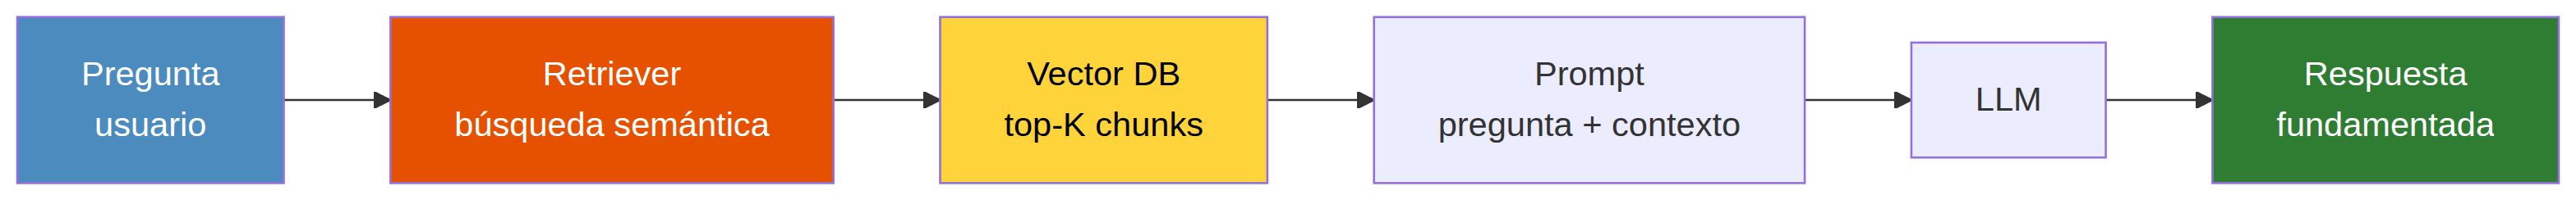

### Output Parsers

Los parsers convierten la salida textual del LLM en objetos Python
utilizables:

In [9]:
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field

class AnalisisDatos(BaseModel):
    metrica_principal: str = Field(description="Nombre de la métrica más relevante")
    valor: float = Field(description="Valor numérico de la métrica")
    tendencia: str = Field(description="'sube', 'baja' o 'estable'")
    recomendacion: str = Field(description="Recomendación de 1 frase")

parser = JsonOutputParser(pydantic_object=AnalisisDatos)

prompt_con_parser = ChatPromptTemplate.from_messages([
    ("system", "Analizas datos empresariales. {formato}"),
    ("user", "Ventas enero: 100, febrero: 120, marzo: 115. ¿Qué ves?")
])

cadena_con_parser = prompt_con_parser | llm | parser

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    resultado = cadena_con_parser.invoke({
        "formato": parser.get_format_instructions()
    })
    print(f"Métrica: {resultado['metrica_principal']}")
    print(f"Valor: {resultado['valor']}")
    print(f"Tendencia: {resultado['tendencia']}")
    print(f"Recomendación: {resultado['recomendacion']}")

Métrica: Ventas
Valor: 115
Tendencia: baja
Recomendación: Monitorear la fluctuación para identificar patrones de crecimiento.

### Callbacks

Los callbacks permiten ejecutar código en puntos clave del pipeline:

In [10]:
from langchain_core.callbacks import BaseCallbackHandler

class MiCallback(BaseCallbackHandler):
    def on_llm_start(self, serialized, prompts, **kwargs):
        print(f"[CALLBACK] Llamando al LLM con {len(prompts)} prompt(s)")

    def on_llm_end(self, response, **kwargs):
        tokens = response.llm_output.get("token_usage", {}).get("total_tokens", "?") if response.llm_output else "?"
        print(f"[CALLBACK] Respuesta recibida. Tokens usados: {tokens}")

cadena = prompt | llm | StrOutputParser()

if not LLM_KEY:
    print("⚠️  Configura LLM_API_KEY en .env para ver el output de esta celda.")
else:
    resultado = cadena.invoke(
        {"concepto": "regresión lineal", "num_palabras": "30"},
        config={"callbacks": [MiCallback()]}
    )
    print(f"\nResultado: {resultado}")

[CALLBACK] Llamando al LLM con 1 prompt(s)
[CALLBACK] Respuesta recibida. Tokens usados: 408

Resultado: La regresión lineal modela la relación entre variables mediante el ajuste de una línea recta a los datos, permitiendo predecir un valor futuro basándose en una variable conocida.

> **Note**
>
> Los callbacks son la base del **tracing** (LangSmith), el **logging**
> y la **monitorización** en producción. Te permiten saber exactamente
> qué está pasando dentro de tus cadenas y cuánto te está costando.

### Resumen del flujo completo

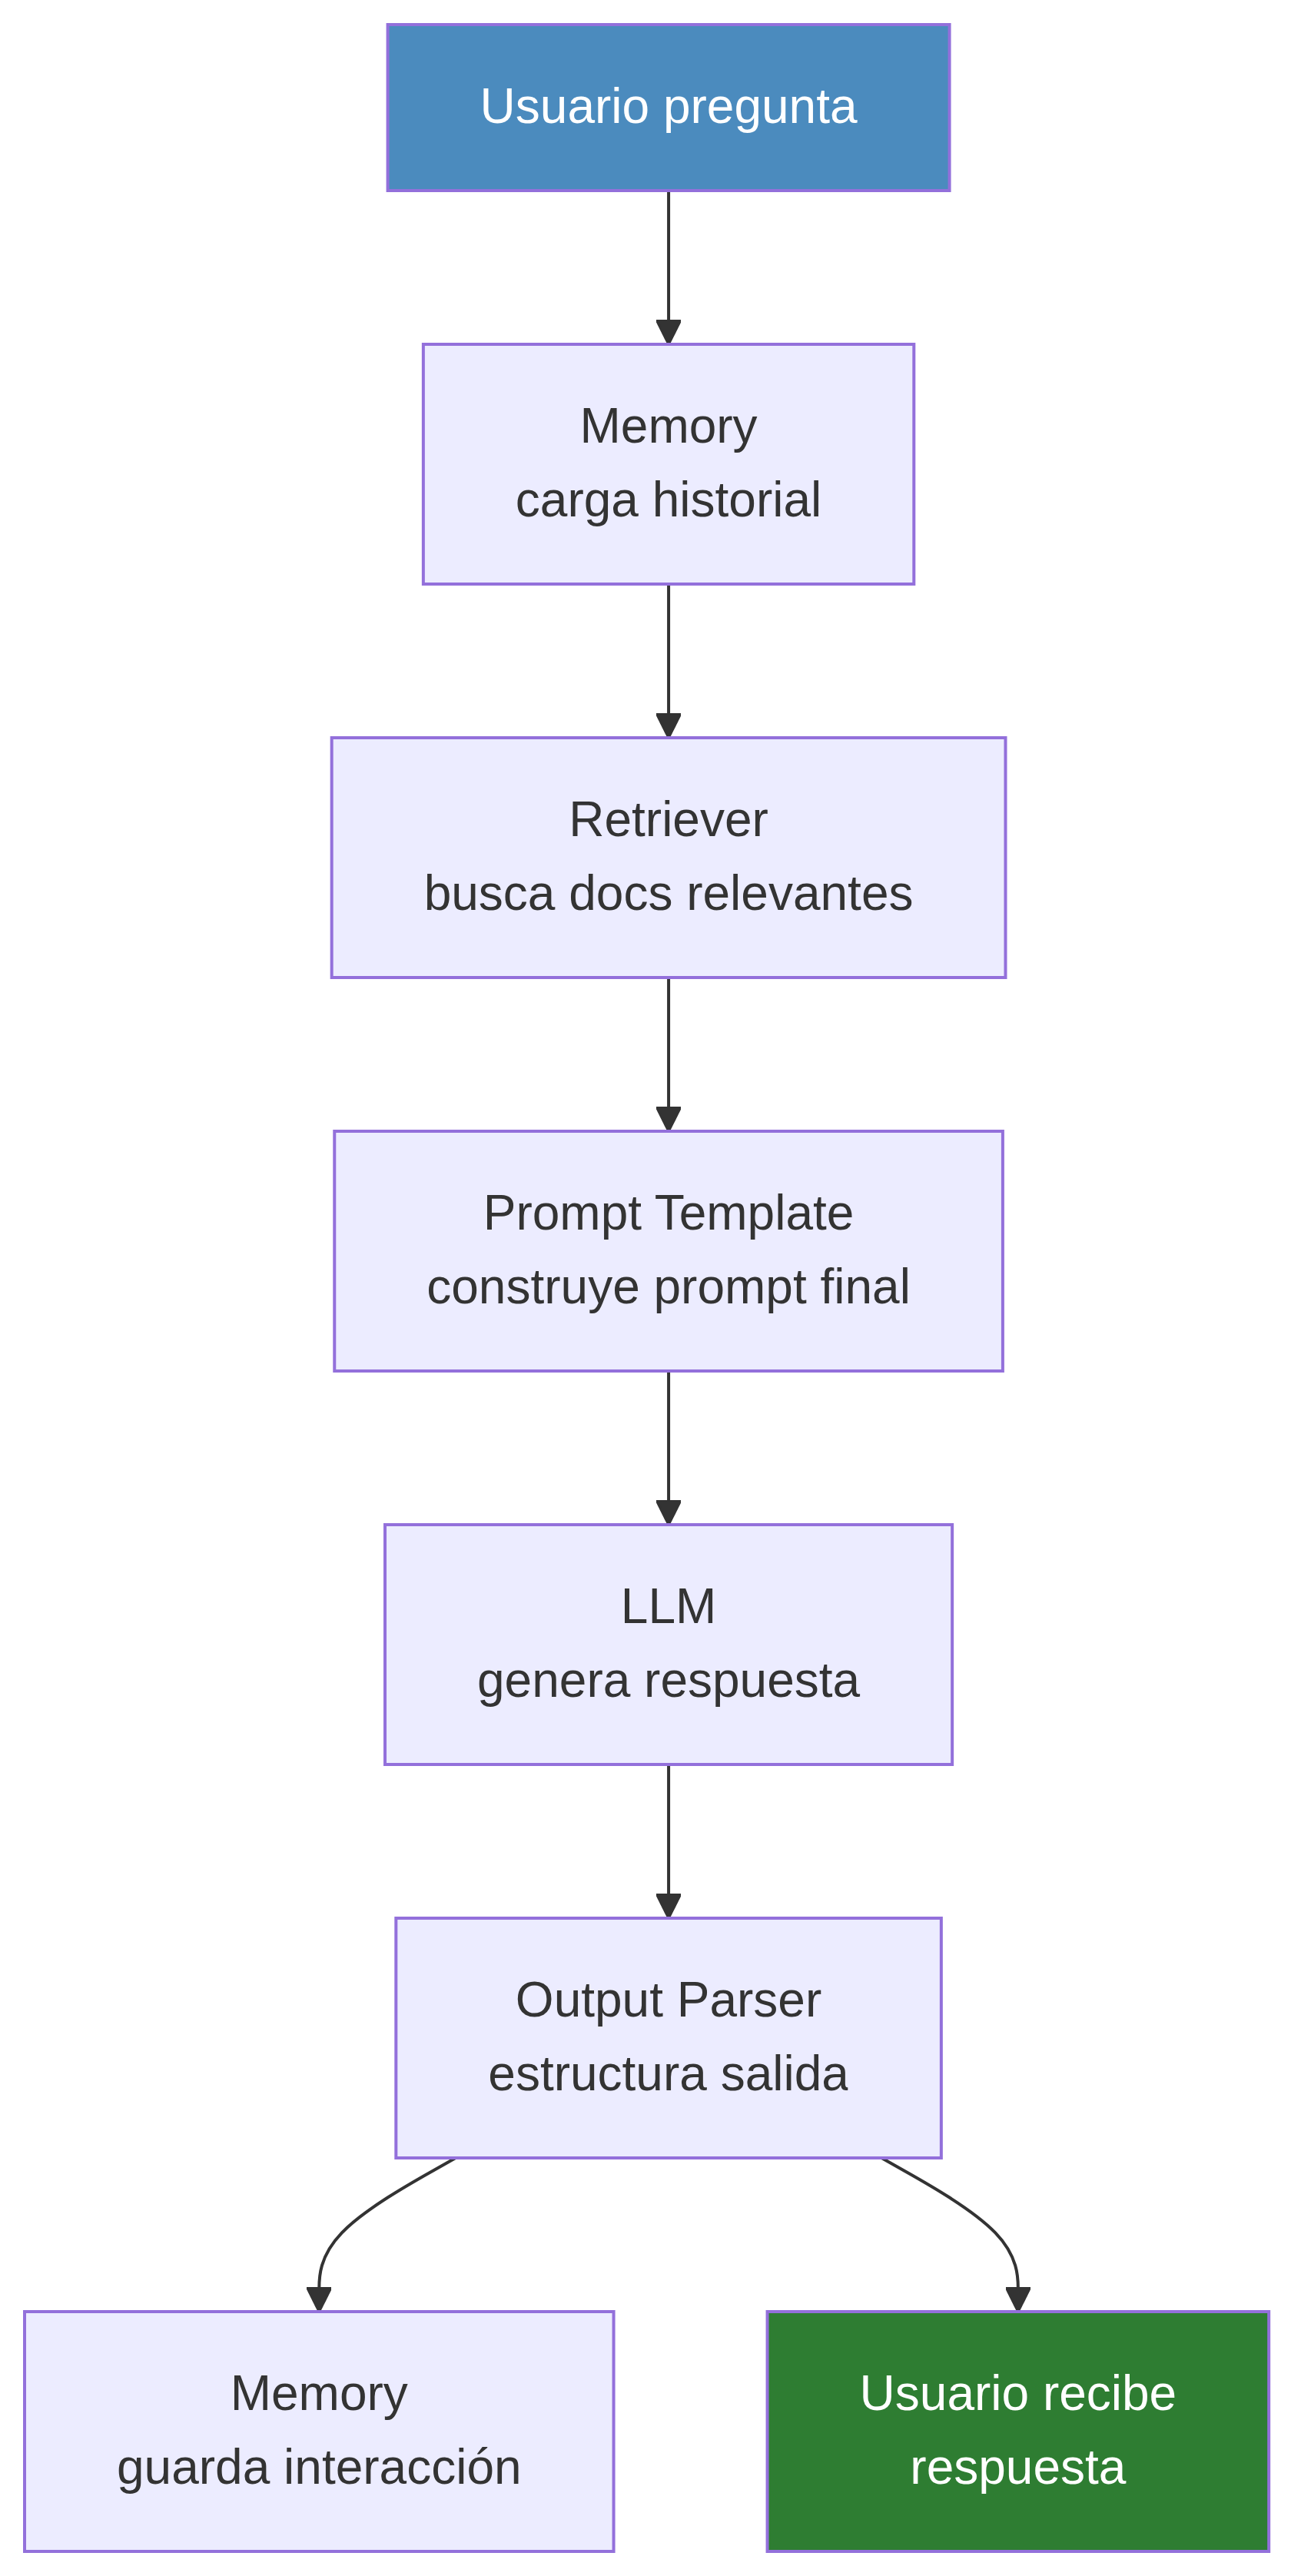

> **Lectura recomendada:** [LangChain Expression Language
> (LCEL)](https://python.langchain.com/docs/concepts/lcel/)